In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [3]:
import pandas as pd

from config import BINANCE_PATH, RESULTS_PATH

as_results = pd.read_parquet(BINANCE_PATH / 'as_test_results.parquet')
symmetric_results = pd.read_parquet(BINANCE_PATH / 'symmetric_test_results.parquet')

In [4]:
import backtest.run

table = pd.DataFrame([backtest.run.summarize(as_results, 'as'), backtest.run.summarize(symmetric_results, 'symmetric')])
table.to_csv(RESULTS_PATH / 'test_comparison.csv', index = False)
print(table)

    strategy  terminal_wealth   spread_pnl    inv_pnl  bid_fills  ask_fills  \
0         as     -1522.450615  1786.911385 -3309.3620      17609      17593   
1  symmetric       385.891664  1907.492164 -1521.6005      19206      19274   

   mean_spread     q_std  mean_abs_q  max_abs_q  
0     9.914458  0.077187    0.062570       0.40  
1     9.914458  0.500539    0.598172       1.28  


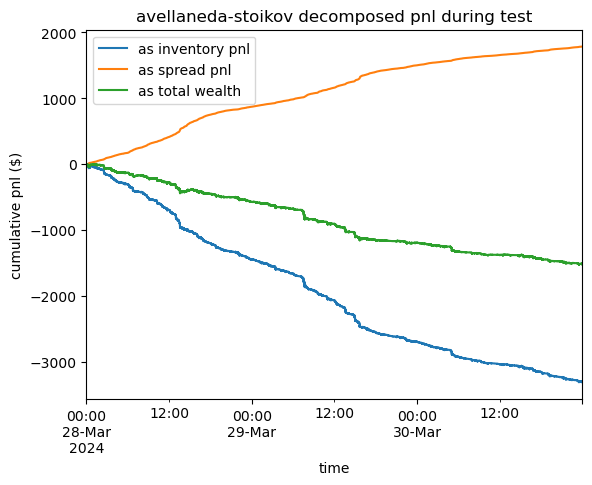

In [5]:
import matplotlib.pyplot as plt

inv_pnl = (as_results['q'].shift() * as_results['mid'].diff()).cumsum() # compute inventory riding market movement
spread_pnl = (as_results['wealth'] - as_results['wealth'].dropna().iloc[0]) - inv_pnl # cash flow

inv_pnl.plot(label = 'as inventory pnl')
spread_pnl.plot(label = 'as spread pnl')
as_wealth = as_results['wealth'].plot(label = 'as total wealth')
plt.legend()
plt.title('avellaneda-stoikov decomposed pnl during test')
plt.xlabel('time')
plt.ylabel('cumulative pnl ($)')
plt.savefig(RESULTS_PATH / 'as_wealth.png', dpi = 150, bbox_inches = 'tight')
plt.show()

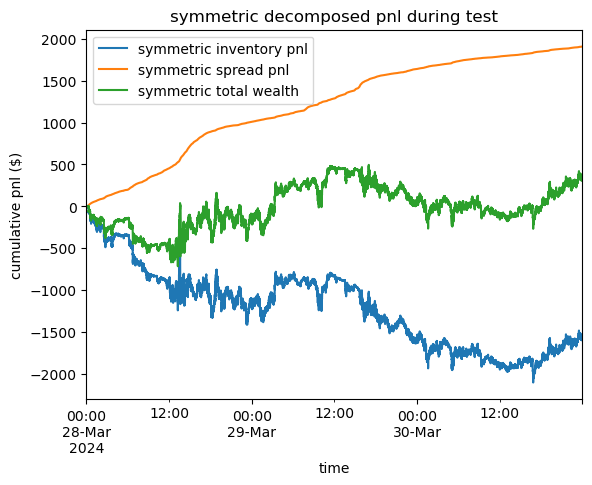

In [6]:
sym_inv_pnl = (symmetric_results['q'].shift() * symmetric_results['mid'].diff()).cumsum() # compute inventory riding market movement
sym_spread_pnl = (symmetric_results['wealth'] - symmetric_results['wealth'].dropna().iloc[0]) - sym_inv_pnl # cash flow

sym_inv_pnl.plot(label = 'symmetric inventory pnl')
sym_spread_pnl.plot(label = 'symmetric spread pnl')
symmetric_results['wealth'].plot(label = 'symmetric total wealth')
plt.legend()
plt.title('symmetric decomposed pnl during test')
plt.xlabel('time')
plt.ylabel('cumulative pnl ($)')
plt.savefig(RESULTS_PATH / 'symmetric_wealth.png', dpi = 150, bbox_inches = 'tight')
plt.show()

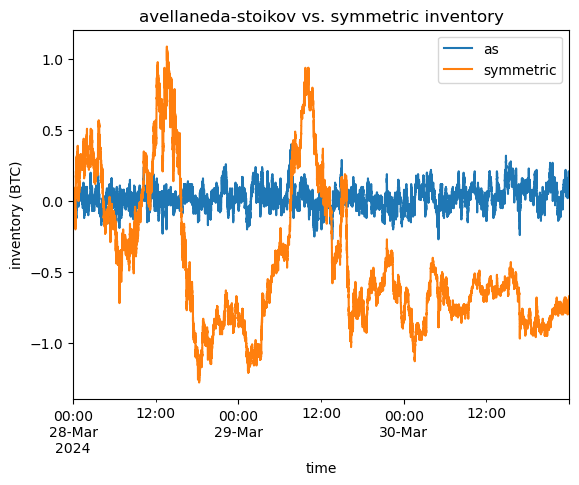

In [7]:
ax = as_results['q'].plot(label = 'as')
symmetric_results['q'].plot(ax = ax, label = 'symmetric')
plt.legend()
plt.title('avellaneda-stoikov vs. symmetric inventory')
plt.xlabel('time')
plt.ylabel('inventory (BTC)')
plt.savefig(RESULTS_PATH / 'inventory.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [8]:
parameters = pd.DataFrame([
    {'parameter': 'A', 'value': '1.13 /s', 'method': 'log-linear fit of λ(δ)', 'source': 'train, δ∈[0.10, 5]'},
    {'parameter': 'k', 'value': '0.47 /$', 'method': 'log-linear fit of λ(δ), slope', 'source': 'train, δ∈[0.10, 5]'},
    {'parameter': 'tau', 'value': '430s', 'method': 'inventory ACF 1/e decay time', 'source': 'train, gamma 1e-3 run'},
    {'parameter': 'half_life', 'value': '15min', 'method': 'QLIKE vs 430s realized variance', 'source': 'train'},
    {'parameter': 'gamma', 'value': '7.2e-4', 'method': 'inventory-variance saturation', 'source': 'gamma sweep, train'},
    {'parameter': 'grid', 'value': '1s', 'method': 'volatility plateau', 'source': 'train'},
    {'parameter': 'quote_size', 'value': '0.01 BTC', 'method': 'fixed (below typical event size)', 'source': '—'},
])
parameters.to_csv(RESULTS_PATH / 'parameters.csv', index=False)